# Project Overview
Given the dataset people.csv, create a KNN model to predict if a person is married or not:
- Nulls in any record invalidates that record.
- What value of K you choose? Why?
- Print a graph showing the best values of K related to the accuray.
- Print the accuracy of the model.
- Is the accuray satisfactory? Why?
- What features do you think could be added to increase the accuracy? Please explain your thoughts.
- Which features contributed the least to the model? Support your answer by showing concrete evidence in your notebook.

# Import Libraries

In [85]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
from mlxtend.feature_selection import SequentialFeatureSelector

# Get Data

In [3]:
df = pd.read_csv('people.csv')

In [4]:
df.head()

,id,first_name,last_name,email,gender,salary,education,Married
0,1,Josi,Millson,jmillson0@youku.com,Female,$152647.10,PhD,False
1,2,Francyne,Rykert,frykert1@list-manage.com,Male,$187810.79,PhD,True
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,Female,$62980.35,MS,True
3,4,Katey,Chick,kchick3@blinklist.com,Female,$87550.97,MS,False
4,5,Sibelle,Molyneaux,smolyneaux4@nyu.edu,Male,$118699.14,BS,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1000 non-null   int64 
 1   first_name  1000 non-null   object
 2   last_name   1000 non-null   object
 3   email       1000 non-null   object
 4   gender      948 non-null    object
 5   salary      1000 non-null   object
 6   education   977 non-null    object
 7   Married     1000 non-null   bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 55.8+ KB


# Nulls in any record invalidates that record.

<Axes: >

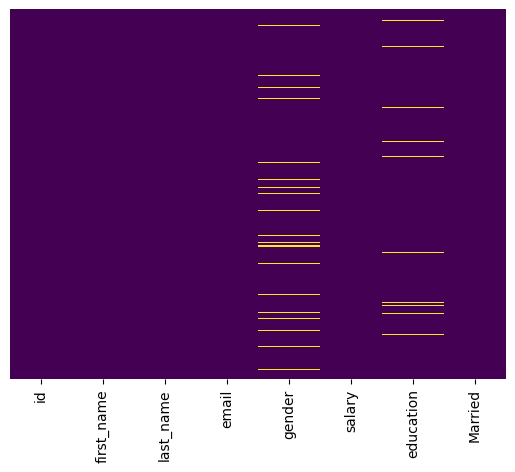

In [6]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [7]:
df.isnull().sum()

id             0
first_name     0
last_name      0
email          0
gender        52
salary         0
education     23
Married        0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1000 non-null   int64 
 1   first_name  1000 non-null   object
 2   last_name   1000 non-null   object
 3   email       1000 non-null   object
 4   gender      948 non-null    object
 5   salary      1000 non-null   object
 6   education   977 non-null    object
 7   Married     1000 non-null   bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 55.8+ KB


In [9]:
df.dropna(inplace=True) 
df.reset_index(drop=True, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          926 non-null    int64 
 1   first_name  926 non-null    object
 2   last_name   926 non-null    object
 3   email       926 non-null    object
 4   gender      926 non-null    object
 5   salary      926 non-null    object
 6   education   926 non-null    object
 7   Married     926 non-null    bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 51.7+ KB


In [11]:
# Se pasaron de 1000 filas a 926

# EDA

## Gender

<Axes: xlabel='gender', ylabel='count'>

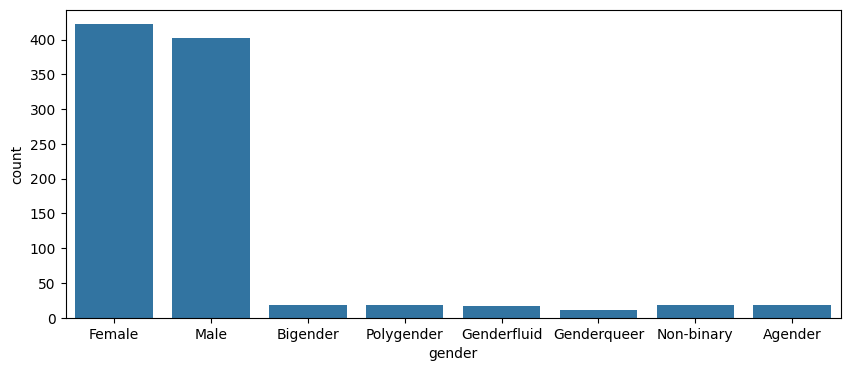

In [12]:
plt.figure(figsize=(10,4))
sns.countplot(x='gender',data=df)

In [15]:
# Calcular los valores absolutos
gender_cant = df['gender'].value_counts()
# Calcular los porcentajes
gender_percent = 100 * gender_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': gender_cant, 'Porcentaje': gender_percent})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

             Cantidad  Porcentaje
gender                           
Female            422       45.57
Male              403       43.52
Non-binary         19        2.05
Bigender           18        1.94
Polygender         18        1.94
Agender            18        1.94
Genderfluid        17        1.84
Genderqueer        11        1.19


In [16]:
# Las categorías que no son Female/Male son dificiles de predecir, podemos agruparlas en una nueva variable 'gender_diverse'
df.loc[~(df['gender'].isin(['Female','Male'])),'gender'] = 'gender_diverse'

gender_cant = df['gender'].value_counts()
gender_cant

gender
Female            422
Male              403
gender_diverse    101
Name: count, dtype: int64

## Education

<Axes: xlabel='education', ylabel='count'>

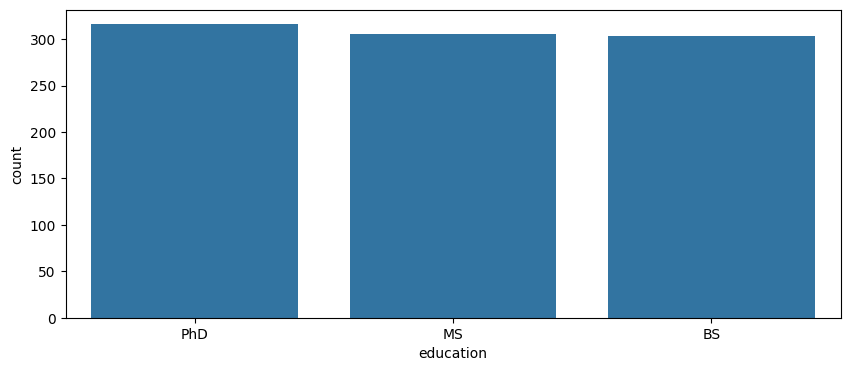

In [17]:
plt.figure(figsize=(10,4))
sns.countplot(x='education',data=df)

In [19]:
# Calcular los valores absolutos
education_cant = df['education'].value_counts()
# Calcular los porcentajes
education_percent = 100 * education_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': education_cant, 'Porcentaje': education_percent})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

           Cantidad  Porcentaje
education                      
PhD             316       34.13
MS              306       33.05
BS              304       32.83


## Married

<Axes: xlabel='Married', ylabel='count'>

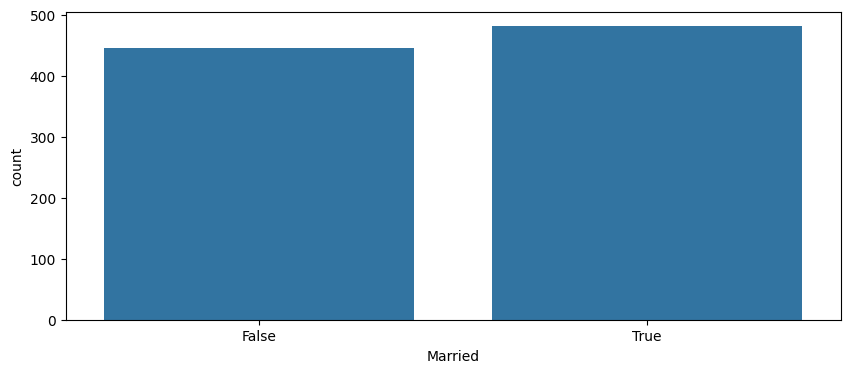

In [20]:
plt.figure(figsize=(10,4))
sns.countplot(x='Married',data=df)

In [21]:
# Calcular los valores absolutos
married_cant = df['Married'].value_counts()
# Calcular los porcentajes
married_percent = 100 * married_cant / len(df)
# Unirlos en un df
result = pd.DataFrame({'Cantidad': married_cant, 'Porcentaje': married_percent})
# Rdondear los porcentajes
result['Porcentaje'] = result['Porcentaje'].round(2)
print(result)

         Cantidad  Porcentaje
Married                      
True          481       51.94
False         445       48.06


## Salary

In [22]:
type(df['salary'].iloc[0])

str

In [23]:
# El salario está en 1 sola moneda?
df['salary'].str[:1].unique()

array(['$'], dtype=object)

In [24]:
# Como está en 1 sola moneda descarto el símbolo y lo paso a float
df['salary'] = df['salary'].str[1:].astype(float)

In [25]:
type(df['salary'].iloc[0])

numpy.float64

Text(0.5, 1.0, 'Histograma de salarios')

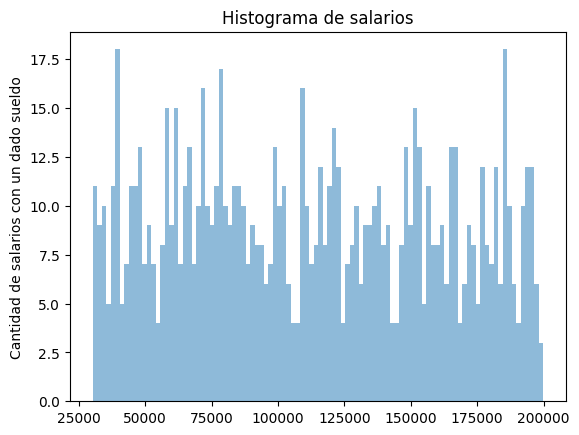

In [26]:
df['salary'].plot.hist(alpha=0.5,bins=100) 
plt.ylabel('Cantidad de salarios con un dado sueldo')
plt.title('Histograma de salarios')

/tmp/ipykernel_97189/2781017246.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['salary'],kde=True,bins=100)


<Axes: xlabel='salary', ylabel='Density'>

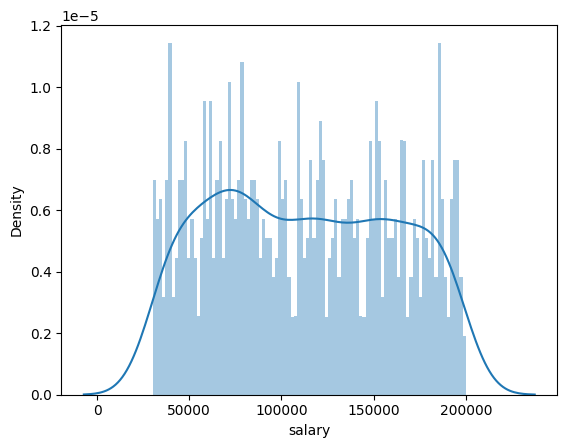

In [27]:
sns.distplot(df['salary'],kde=True,bins=100) 

# Since Salary has a wide range, it requires some kind of treatment before use.

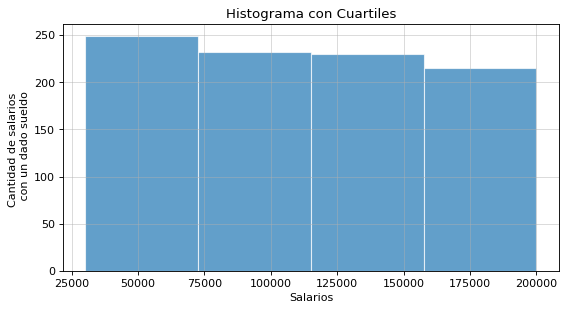

In [28]:
# Una opción sería usar cuartiles

quartiles = df['salary'].quantile([0.25, 0.5, 0.75])

plt.figure(figsize=(8,4), dpi=80)
plt.hist(df['salary'], bins=4, edgecolor='white', alpha=0.7)
plt.xlabel('Salarios')
plt.ylabel('Cantidad de salarios \n con un dado sueldo')
plt.title('Histograma con Cuartiles')
plt.grid(alpha=0.5)
plt.show()

In [ ]:
#df['salary_quartil'] = pd.qcut(df['salary'],
#                                      q=np.arange(0,1.1,0.25),
#                                      labels=np.arange(1,5,1))

In [29]:
# Voy a emplear escalado/normalización, que transforma los salarios para que estén en un rango más manejable
df['salary'] = (df['salary'] - min(df['salary'])) / (max(df['salary']) - min(df['salary']))

In [30]:
df.head()

,id,first_name,last_name,email,gender,salary,education,Married
0,1,Josi,Millson,jmillson0@youku.com,Female,0.721224,PhD,False
1,2,Francyne,Rykert,frykert1@list-manage.com,Male,0.928379,PhD,True
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,Female,0.192983,MS,True
3,4,Katey,Chick,kchick3@blinklist.com,Female,0.337733,MS,False
4,5,Sibelle,Molyneaux,smolyneaux4@nyu.edu,Male,0.521231,BS,False


# Data Transformation: Categorical Features

In [31]:
cat_feats = ['gender','education','Married']
cat_feats

['gender', 'education', 'Married']

In [32]:
# A df le agregamos al final columnas que son los valores que vienen en las columnas categóricas del original, y les ponemos 0 o 1
final_data = pd.get_dummies(df,columns=cat_feats,drop_first=True)
     #drop_first=True: De cada variable categórica elimina la primera categoría (evita variables dummies redundantes).
final_data.head()

,id,first_name,last_name,email,salary,gender_Male,gender_gender_diverse,education_MS,education_PhD,Married_True
0,1,Josi,Millson,jmillson0@youku.com,0.721224,False,False,False,True,False
1,2,Francyne,Rykert,frykert1@list-manage.com,0.928379,True,False,False,True,True
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,0.192983,False,False,True,False,True
3,4,Katey,Chick,kchick3@blinklist.com,0.337733,False,False,True,False,False
4,5,Sibelle,Molyneaux,smolyneaux4@nyu.edu,0.521231,True,False,False,False,False


# Create a KNN model to predict if a person is married or not.

In [33]:
# ['salary', 'education', 'Female', 'Male', 'Others']

In [34]:
# ID, Name, Surname and E-mail address do not matter for the measurement.
features_X = final_data.drop(['Married_True', 'email', 'last_name','first_name','id'], axis=1)
features_X.head()

,salary,gender_Male,gender_gender_diverse,education_MS,education_PhD
0,0.721224,False,False,False,True
1,0.928379,True,False,False,True
2,0.192983,False,False,True,False
3,0.337733,False,False,True,False
4,0.521231,True,False,False,False


In [35]:
features_y = final_data['Married_True']

## Train Test Split
Use train_test_split to split your data into a training set and a testing set.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(features_X, features_y, 
                                                    test_size=0.2, 
                                                    random_state=42)

## What value of K you choose? Why?
Use the elbow method to pick a good K Value!

In [51]:
error_rate = []

# Will take some time
for i in range(1,40):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

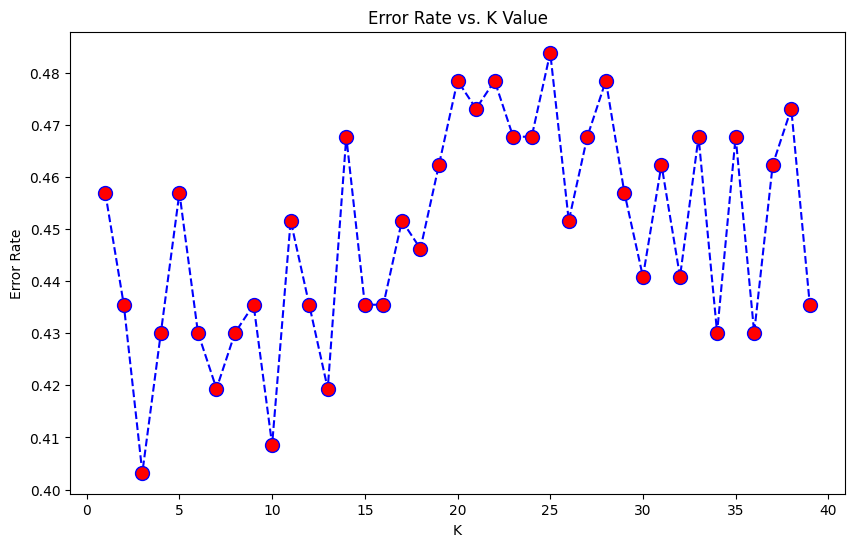

In [52]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

## Otra forma de elegir K

In [50]:
k_values = list(range(1, 21))

# Definido la grilla, el modelo, y hago el fit.
param_grid = {'n_neighbors': k_values}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, 
                           param_grid, 
                           cv=5, 
                           scoring='accuracy', 
                           return_train_score=True)

grid_search.fit(X_train, y_train)

# Guardo los resultados.
results = grid_search.cv_results_

## Print a graph showing the best values of K related to the accuray.

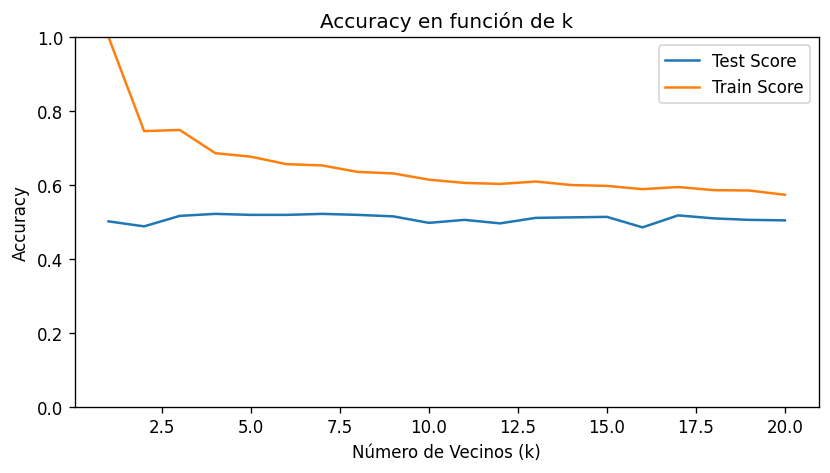

In [53]:
# Grafico la media de accuracy para los 5 searchs realizados en el paso anterior. Pongo la escala entre 0 y 1 para no sugestionar
# con la escala.
plt.figure(figsize=(8, 4), dpi=120)
plt.plot(k_values, results['mean_test_score'], label='Test Score')
plt.plot(k_values, results['mean_train_score'], label='Train Score')
plt.title('Accuracy en función de k')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0,1)
plt.show()

In [58]:
# Dado que observé que la gráfica no tiene "cosas extrañas" (por ejemplo, accuracy en train mucho mayor que en test, dando a entender
# que el modelo se aprendió el train de memoria y es malo ajustando el test, etc. etc.) elijo el valor mayor de accuracy en el test
best_k = grid_search.best_params_['n_neighbors']
print(f"El mejor valor de k es: {best_k}")

El mejor valor de k es: 4


## Using KNN

In [66]:
# knn = KNeighborsClassifier(n_neighbors=1)
# knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn = KNeighborsClassifier(n_neighbors=best_k)

In [67]:
best_knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4)

## Predictions and Evaluations

In [68]:
pred = best_knn.predict(X_test)

In [75]:
print('\n Matriz de confusion\n',confusion_matrix(y_test,pred))
print('\n \n')
print('Verdaderos positivos(TP) = ', cm[0,0])
print('Verdaderos negativos(TN) = ', cm[1,1])
print('Falsos negativos(FN) = ', cm[0,1])
print('Falsos positivos (FP) = ', cm[1,0])


 Matriz de confusion
 [[69 24]
 [56 37]]

 

Verdaderos positivos(TP) =  69
Verdaderos negativos(TN) =  37
Falsos negativos(FN) =  24
Falsos positivos (FP) =  56


In [76]:
print('\n Reporte final: \n')
print(classification_report(y_test,pred))


 Reporte final: 

              precision    recall  f1-score   support

       False       0.55      0.74      0.63        93
        True       0.61      0.40      0.48        93

    accuracy                           0.57       186
   macro avg       0.58      0.57      0.56       186
weighted avg       0.58      0.57      0.56       186



## Print the accuracy of the model.

In [77]:
# Calcular la precisión en el conjunto de prueba
accuracy = accuracy_score(y_test, best_knn.predict(X_test))
print(f"Precisión en test: {accuracy:.2f}")


Precisión en test: 0.57


## Is the accuray satisfactory? Why?

In [82]:
random_prediction = np.random.binomial(n=1, p=0.5, size=len(df))

accuracy_random_prediction = accuracy_score(df.Married.astype('int'), random_prediction)

print("Precisión en predicción aleatoria: ", accuracy_random_prediction)

Precisión en predicción aleatoria:  0.49676025917926564


In [100]:
accuracy_score(final_data.Married_True.astype('int'), random_prediction)


0.49676025917926564

Conclusiones:
- El valor de k es razonable: con 4 vecinos es sufiente para saber que valor de verdad asignar a 'Married_True' para un registro nuevo.
- Sin embargo, el valor de precisión es muy bajo. De los predichos positivos (69+56=125) solo se detectaron 69, es decir 69/125 = 0.552 de precisión. De los negativos (37+24=61) se detectaron 37, es decir 37/61 = 0.606 de precisión.
- Como vemos la precisión es un poco superior a la precisión en predicción aleatoria, pero los resultados podrían ser mejores. No es un buen resultado.

## What features do you think could be added to increase the accuracy? Please explain your thoughts.

*Los features que podrían agregarse en pos de intentar aumentar la accuracy son:*

I- *edad: Esta categoría puede brindar información por diversos factores, uno de ellos es que a mayor edad la persona tuvo más tiempo para casarse.*

II- *religión: Esta categoría podría tener matices dependiendo las religiones involucradas. Su utilidad radica en que las religiones fomentan la unión de las parejas y aumenta la probabilidad de que las personas estén casadas.*


## Which features contributed the least to the model? Support your answer by showing concrete evidence in your notebook.

In [ ]:
# Para realizar el feature importance, utilizo un selector de features que va recalculando métricas eliminando features y evalúa
# si importancia en función de la degradación de las métricas.

knn = KNeighborsClassifier(n_neighbors=best_k)
sfs = SequentialFeatureSelector(knn, k_features='best', forward=True, scoring='accuracy', cv=5)
    #Se crea un selector secuencial de características (SequentialFeatureSelector).
    # forward=True: selección hacia adelante ("forward selection"): empieza sin ningún feature, y va agregando de a uno el que mejor mejora la métrica.
    # scoring='accuracy': usa la precisión como métrica para evaluar los subconjuntos de features.
    # cv=5: validación cruzada de 5 folds para asegurar estabilidad del cálculo.
sfs.fit(X_train, y_train)
    # El selector se ajusta sobre los datos de entrenamiento (X_train, y_train).
selected_features = list(sfs.k_feature_names_)
    # selected_features contendrá los nombres de las columnas elegidas como mejores por el selector secuencial.

# Como indicio de buen funcionamiento, recalculo el modelo solo con los features seleccionados. 
knn.fit(X_train[selected_features], y_train)
accuracy = accuracy_score(y_test, knn.predict(X_test[selected_features]))
print(f"Accuray nuevo: {accuracy:.2f}")
print("Features seleccionados:", selected_features)

Accuray nuevo: 0.50
Features seleccionados: ['gender_gender_diverse']


 Observo que la precisión con esta nueva elección ha bajado 0.07. Los features eliminados fueron:
 - salary
 - gender_Male
 - education_MS
 - education_PhD

Se puede concluir que casi ninguna de las categorías de forma individual brinda información crucial al modelo. Esto es esperable debido a que la predicción obtenida no es muy superior a una predicción aleatoria.

Otras cosas que se pueden hacer pero que no hago para no extenderme:
- Realizar los gráficos de barras de features en función de Married_True 0 o 1, como hice en 2, para inspeccionar visualmente la importancia de tales features. 
- Muchas veces me gusta hacer un pipeline de sklearn para probar varios modelos. O bien, librerías nuevas más ágiles como pycaret. De paso, los uso como validación rápida para mi modelo viendo que las métricas sean parecidas. 

## Otra Opción

Para verificar la contribución de los features al modelo, se puede reordenar sus elementos de forma aleatoria, con el objetivo de ver un cambio significativo en la respuesta del modelo. En caso contrario, si el accuracy se mantiene significaría que el aporte de la categoría no es considerablemente significativa para el modelo.

Se realiza esta distribución aleatoria de las categorías education, salary, gender por separado. Para ello, se toman los datos de la categoría a explorar y se distribuyen sus elementos de forma aleatoria entre las distintas personas. Se repite el proceso para cada categoría y se imprimen los valores de accuracy para el dataset sin modificar y para los 3 dataset modificados.

In [122]:
final_data.head()

,id,first_name,last_name,email,salary,gender_Male,gender_gender_diverse,education_MS,education_PhD,Married_True
0,1,Josi,Millson,jmillson0@youku.com,0.721224,False,False,False,True,False
1,2,Francyne,Rykert,frykert1@list-manage.com,0.928379,True,False,False,True,True
2,3,Fransisco,Muddimer,fmuddimer2@reuters.com,0.192983,False,False,True,False,True
3,4,Katey,Chick,kchick3@blinklist.com,0.337733,False,False,True,False,False
4,5,Sibelle,Molyneaux,smolyneaux4@nyu.edu,0.521231,True,False,False,False,False


In [127]:
feat_X = ['salary', 'gender_Male', 'gender_gender_diverse', 'education_MS','education_PhD' ]
feat_y = ['Married_True']

In [106]:
### random values education_MS
df_random_education_ms = final_data.copy()
df_random_education_ms['education_MS'] = np.random.permutation(df_random_education_ms['education_MS'])
X_ed_MS = df_random_education_ms[feat_X]

In [107]:
### random values education_PhD
df_random_educatio_phd = final_data.copy()
df_random_educatio_phd['education_PhD'] = np.random.permutation(df_random_educatio_phd['education_PhD'])
X_ed_PhD = df_random_educatio_phd[feat_X]

In [117]:
### random values gender_Male
df_random_gender_male = final_data.copy()
df_random_gender_male['gender_Male'] = np.random.permutation(df_random_gender_male['gender_Male'])
X_gd_Male = df_random_gender_male[feat_X]

In [118]:
### random values gender_gender_diverse
df_random_gender_gender_diverse = final_data.copy()
df_random_gender_gender_diverse['gender_gender_diverse'] = np.random.permutation(df_random_gender_gender_diverse['gender_gender_diverse'])
X_gd_gd = df_random_gender_gender_diverse[feat_X]

In [120]:
### random values salary
df_random_salary = final_data.copy()
df_random_salary['salary'] = np.random.permutation(df_random_salary['salary'])
X_sl = df_random_salary[feat_X]

In [130]:
X = final_data[feat_X]
y = final_data[feat_y]

datasets = [X, X_ed_MS,X_ed_PhD, X_gd_Male,X_gd_gd,X_sl]
titles = ['without changes', 'randomization - education MS','randomization - education PhD' ,'randomization - gender Male','randomization - gender gd', 'randomization - salary']
k = 15
cv = 10

for i in range(len(datasets)):
    kNN = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(kNN, datasets[i], y.values.ravel(), cv=cv)  
    accuracy = (np.mean(score))
    display(f'Accuracy | {titles[i]}:  {accuracy}')


'Accuracy | without changes:  0.5366526414212249'

'Accuracy | randomization - education MS:  0.5076320710612435'

'Accuracy | randomization - education PhD:  0.5290906965871903'

'Accuracy | randomization - gender Male:  0.48274894810659186'

'Accuracy | randomization - gender gd:  0.5292192613370734'

'Accuracy | randomization - salary:  0.489107059373539'

¿Qué esperas normalmente?
- Si aleatorizas una columna importante para la predicción, la accuracy debería bajar: porque esa información se volvió ruido.
- Si aleatorizas una columna no importante, la accuracy no cambia (o cambia poco).
- Si aleatorizas una columna irrelevante o ruido, incluso la accuracy podría mejorar si antes esa columna metía ruido.